## <u>Python for AI-ML</u>

# Module 4 - Data Preprocessing

# Use Case-1: Bello Fashions


### Problem Statement
The data analysis team has been given a task to analyze the monthly sales by the manager.

### Import Basic Libraries

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive

Mounted at /content/gdrive


In [3]:
# !cp /content/db_bello_customers.db /mydrive/NITW-01-Python/04-01-db_bello_customers.db
# !cp /content/lcl_bello_sales.xlsx /mydrive/NITW-01-Python/04-01-lcl_bello_sales.xlsx

!cp /mydrive/NITW-01-Python/04-01-db_bello_customers.db /content/db_bello_customers.db 
!cp /mydrive/NITW-01-Python/04-01-lcl_bello_sales.xlsx /content/lcl_bello_sales.xlsx 

### Reading Data from Multiple Sources

Richard reads data from multiple sources using pandas and merges into a single flat file(CSV). Later, he shares this file to Robin to perform the Data Analyst.

In [4]:
from sqlalchemy import create_engine

In [5]:
engine=create_engine('sqlite:///db_bello_customers.db')

In [6]:
on_premise_db=pd.read_sql_table('Payments',engine.connect())

In [ ]:
on_premise_db.head()

,Date,CustomerID,PaymentMode,ShippingMode,Gender,ShippingTime
0,16/08/20,10471,Creditcard,Economy,Female,17.0
1,2/8/2020 0:00,10472,Ewallet,Mail,Unspecified,12.0
2,8/8/2020 0:00,10473,Prepaid Card,Mail,None,10.0
3,None,10474,Directdeposit,Normal,Female,2133.0
4,24/08/20,10475,None,Economy,Male,2133.0


In [7]:
cld_data=pd.read_csv('https://raw.githubusercontent.com/SameerJain901/datasets/master/cld_bello_customers.csv')

In [ ]:
cld_data.head()

,CustomerID,ProductType,Rating,Total_Ratings,PaymentMode
0,10471,coates,1 start,8736,Creditcard
1,10472,dresses,2 star,8547,Ewallet
2,10473,NaN,2 star,9833,Prepaid Card
3,10474,dresses,2star,7591,Directdeposit
4,10475,pantas,1 start,5131,NaN


In [8]:
lcl_data=pd.read_excel('lcl_bello_sales.xlsx')

In [ ]:
lcl_data.head()

,CustomerID,Price
0,10471,₹ 675036.2138626401
1,10472,"€ 2,315.53"
2,10473,₹ 611426.29122378
3,10474,₹ 210869.48083470002
4,10475,₹ 679422.2811434


In [9]:
# Checking shape of all the DataFrames
lcl_data.shape,cld_data.shape,on_premise_db.shape

((100, 2), (100, 5), (100, 6))

In [10]:
# Remove the columns CustomerID from other two DataFrames as they are present in cld_data
lcl_data.drop('CustomerID',axis=1,inplace=True)
on_premise_db.drop('CustomerID',axis=1,inplace=True)
on_premise_db.drop('PaymentMode',axis=1,inplace=True)

Now, we have to merge them into one single file so that Robin can analyze the data.

In [11]:
data = pd.concat([cld_data,on_premise_db,lcl_data],axis=1)

In [12]:
data.shape

(100, 10)

In [13]:
data.head()

,CustomerID,ProductType,Rating,Total_Ratings,PaymentMode,Date,ShippingMode,Gender,ShippingTime,Price
0,10471,coates,1 start,8736,Creditcard,16/08/20,Economy,Female,17.0,₹ 675036.2138626401
1,10472,dresses,2 star,8547,Ewallet,2/8/2020 0:00,Mail,Unspecified,12.0,"€ 2,315.53"
2,10473,NaN,2 star,9833,Prepaid Card,8/8/2020 0:00,Mail,None,10.0,₹ 611426.29122378
3,10474,dresses,2star,7591,Directdeposit,None,Normal,Female,2133.0,₹ 210869.48083470002
4,10475,pantas,1 start,5131,NaN,24/08/20,Economy,Male,2133.0,₹ 679422.2811434


In [14]:
data.reset_index(inplace=True)

In [15]:
# Arrange the columns
data = data[['Date','CustomerID','ProductType','Rating','Total_Ratings','Gender',
                                'PaymentMode','ShippingMode','ShippingTime','Price']]    
data.head()                

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
0,16/08/20,10471,coates,1 start,8736,Female,Creditcard,Economy,17.0,₹ 675036.2138626401
1,2/8/2020 0:00,10472,dresses,2 star,8547,Unspecified,Ewallet,Mail,12.0,"€ 2,315.53"
2,8/8/2020 0:00,10473,NaN,2 star,9833,None,Prepaid Card,Mail,10.0,₹ 611426.29122378
3,None,10474,dresses,2star,7591,Female,Directdeposit,Normal,2133.0,₹ 210869.48083470002
4,24/08/20,10475,pantas,1 start,5131,Male,NaN,Economy,2133.0,₹ 679422.2811434


In [16]:
# Saving the data
data.to_csv('/content/Bello_Customers.csv',index=False)

### Duplicate Entries

In [17]:
uncleaned = pd.read_csv('/content/Bello_Customers.csv')

In [18]:
data = uncleaned.copy()
data.shape

(100, 10)

In [ ]:
# Returns boolean series denoting duplicate rows
data.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [ ]:
# Let's see which rows are duplicates
data[data.duplicated()]

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
88,31/08/20,10558,coates,5 star,7007,Unspecified,Credit Card,Normal,11.0,₹ 234895.78095268
89,31/08/20,10558,coates,5 star,7007,Unspecified,Credit Card,Normal,11.0,₹ 234895.78095268


In [ ]:
# original entry
# data.iloc[87,:]
data[data['CustomerID']==10558]

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
87,31/08/20,10558,coates,5 star,7007,Unspecified,Credit Card,Normal,11.0,₹ 234895.78095268
88,31/08/20,10558,coates,5 star,7007,Unspecified,Credit Card,Normal,11.0,₹ 234895.78095268
89,31/08/20,10558,coates,5 star,7007,Unspecified,Credit Card,Normal,11.0,₹ 234895.78095268


In [19]:
# Dropping duplicate entries where inplace attribute ensures that the change is updated in the DataFrame 
data.drop_duplicates(inplace=True)
data.shape, uncleaned.shape

((98, 10), (100, 10))

Even the change after dropping duplicates seems very little, it generates inconsistent results and would have been harmful to the industry in the long run.

### Outliers - Shipping Time

In [ ]:
#data[['ShippingTime']].boxplot()
# data.boxplot()
shipTimeMean = data['ShippingTime'].mean()
shipTimeMedian = data['ShippingTime'].median()
shipTimeMean, shipTimeMedian

(114.10309278350516, 13.0)

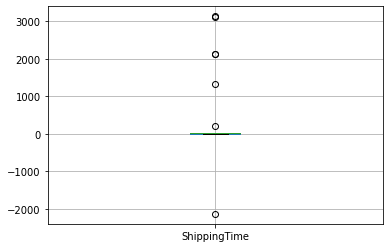

In [ ]:
data.boxplot(column='ShippingTime')

In [20]:
# Pandas allows you to get quantiles using quantile function
Q1 = data['ShippingTime'].quantile(0.25)
Q3 = data['ShippingTime'].quantile(0.75)
IQR = Q3 - Q1
LowerCutoff = Q1 - 1.5*IQR
HigherCutoff = Q3 + 1.5* IQR
print(Q1, Q3, IQR, LowerCutoff, HigherCutoff)

9.0 18.0 9.0 -4.5 31.5


In [21]:
# outliers=data[(data.ShippingTime < (Q1 - 1.5 * IQR)) |(data.ShippingTime > (Q3 + 1.5 * IQR))]
data[(data['ShippingTime'] < LowerCutoff) | (data['ShippingTime'] > HigherCutoff)]

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
3,NaN,10474,dresses,2star,7591,Female,Directdeposit,Normal,2133.0,₹ 210869.48083470002
4,24/08/20,10475,pantas,1 start,5131,Male,NaN,Economy,2133.0,₹ 679422.2811434
27,19/08/20,10498,Coats/Jackets,3 star,9297,Unspecified,Direct Deposit,Express,213.0,₹ 635118.07344224
43,14/08/20,10514,dresses,5 star,5567,Unspecified,Credit Card,Express,1321.0,"€ 7,261.79"
59,17/08/20,10530,Cardigan,4 star,6930,Female,Cash,Economy,3113.0,"$8,670.69"
71,20/08/20,10542,Hats,2star,9157,Male,Cash,Mail,3132.0,₹ 708227.40839738
98,26/08/20,10569,Pants,5 star,5200,Male,Directdeposit,Economy,-2131.0,£ 4118.0053827500005


In [22]:
data.drop([3, 4, 27, 43, 59, 71, 98], axis=0, inplace=True)
data.shape

(91, 10)

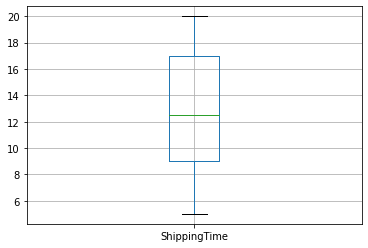

In [23]:
# No outliers present in the data
data.boxplot(column='ShippingTime') # You can also specify the names of columns you want to plot for.

In [ ]:
# Let's check the total shipping time before and after remvoging outliers
print('Before: ', round(uncleaned.ShippingTime.mean(),3))
print('After: ',round(data.ShippingTime.mean(),3))
print('Difference: ',round(uncleaned.ShippingTime.mean()-data.ShippingTime.mean(),3))

Before:  112.02
After:  12.822
Difference:  99.198


That is really extreme change in values. This would have caused serious harm to the company.

### Empty Records/Values

In [ ]:
# Let's see if there are any null values or not
#data.isnull().values.any()
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 91 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           91 non-null     object 
 1   CustomerID     91 non-null     int64  
 2   ProductType    87 non-null     object 
 3   Rating         85 non-null     object 
 4   Total_Ratings  91 non-null     int64  
 5   Gender         86 non-null     object 
 6   PaymentMode    86 non-null     object 
 7   ShippingMode   88 non-null     object 
 8   ShippingTime   90 non-null     float64
 9   Price          90 non-null     object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.8+ KB


In [ ]:
#data[data.Date.isna()]
data[data.Rating.isna()]

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
7,8/8/2020 0:00,10478,Jeans,NaN,8554,Unspecified,Direct Deposit,Mail,18.0,"$4,287.06"
13,2/8/2020 0:00,10484,Coats/Jackets,NaN,5024,Male,Mobile Payment,Express,18.0,"$3,148.65"
19,14/08/20,10490,Shirts/Tops,NaN,9296,Female,NaN,Economy,17.0,"$6,221.36"
36,11/8/2020 0:00,10507,dresses,NaN,5848,Male,Direct Deposit,Economy,19.0,£ 7236.8351195000005
38,29/08/20,10509,Jeans,NaN,7352,Unspecified,Creditcard,Express,9.0,"$2,591.72"
65,31/08/20,10536,Jeans,NaN,6878,Male,Prepaid Card,Express,10.0,"$7,072.56"


In [24]:
# First we have to change the DataTypes for all the required columns
data.ProductType=data.ProductType.astype('string')
data.PaymentMode=data.PaymentMode.astype('string')
data.Rating=data.Rating.astype('category')
data.Gender=data.Gender.astype('category')
data.PaymentMode=data.PaymentMode.astype('category')
data.ShippingMode=data.ShippingMode.astype('string')
data.Price=data.Price.astype('string')

In [25]:
# ProductType, and PaymentMode can be filled with mode
# While State can be filled with NA, Gender with Unspecified
# We can fill Price with mean values as we have made a sale for that day
data.ProductType.fillna(data.ProductType.mode()[0],inplace=True)
data.PaymentMode.fillna(data.PaymentMode.mode()[0],inplace=True)
data.Gender.fillna('Unspecified',inplace=True)
data.Rating.fillna(data.Rating.mode()[0],inplace=True)
data.ShippingMode.fillna(data.ShippingMode.mode()[0],inplace=True)
data.ShippingTime.fillna(data.ShippingTime.mean(),inplace=True)

In [ ]:
# Checking for missing data again
# check_miss(data)
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 91 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Date           91 non-null     object  
 1   CustomerID     91 non-null     int64   
 2   ProductType    91 non-null     string  
 3   Rating         91 non-null     category
 4   Total_Ratings  91 non-null     int64   
 5   Gender         91 non-null     category
 6   PaymentMode    91 non-null     category
 7   ShippingMode   91 non-null     string  
 8   ShippingTime   91 non-null     float64 
 9   Price          90 non-null     string  
dtypes: category(3), float64(1), int64(2), object(1), string(3)
memory usage: 6.6+ KB


We still have to fill empty Price column but it is quite hard due to different currencies.

### Manipulating Values

There are typos in ProductType and some other columns

In [ ]:
data['ProductType'].unique()

<StringArray>
[       'coates',      'dresses ', 'Coats/Jackets',         'Jeans',
        'pantas',         'Pants',      'Cardigan',       'Dresses',
   'Shirts/Tops',          'Hats']
Length: 10, dtype: string

In [ ]:
# ['ProductType','PaymentMode','Gender','Rating','ShippingMode']
productTypes = [item for item in data.ProductType.unique()]
paymentModes = [item for item in data.PaymentMode.unique()]
genders = [item for item in data.Gender.unique()]
ratings = [item for item in data.Rating.unique()]
shippingModes = [item for item in data.ShippingMode.unique()]
print(productTypes)
print(paymentModes)
print(genders)
print(ratings)
print(shippingModes)


['coates', 'dresses ', 'Coats/Jackets', 'Jeans', 'pantas', 'Pants', 'Cardigan', 'Dresses', 'Shirts/Tops', 'Hats']
['Creditcard', 'Ewallet', 'Prepaid Card', 'Direct Deposit', 'Mobile Payment', 'Cash', 'Mobile', 'Credit Card', 'Directdeposit']
['Female', 'Unspecified', 'Male']
['1 start', '2 star', '5 star', '4 star', '2star', '3 star']
['Economy', 'Mail', 'Express', 'Normal']


Typing errors: 
- __coates__ should be _Coats/Jackets_
- __dresses__ should be _Dresses_
- __pantas__ should be _Pants_
- __Creditcard__ should be _Credit Card_
- __Directdeposit__ should be _Direct Deposit_
- __2star__ should be _2 star_

In [26]:
# Manipulating the values
def rectifyProductTypes(i):
    if i=='coates':
        return 'Coats/Jackets'
    elif i=='dresses ':
        return 'Dresses'
    elif i=='pantas':
        return 'Pants'
    else:
        return i

def rectifyPaymentModes(i):
    if i=='Creditcard':
        return 'Credit Card'
    elif i=='Directdeposit':
        return 'Direct Deposit'
    else:
        return i

def rectifyRatings(i):
    if i=='2star':
        return '2 star'
    elif i=='1 start':
        return '1 star'
    else:
        return i

data.ProductType = data.ProductType.apply(rectifyProductTypes)
data.PaymentMode=data.PaymentMode.apply(rectifyPaymentModes)
data.Rating=data.Rating.apply(rectifyRatings)

In [27]:
productTypes = [item for item in data.ProductType.unique()]
paymentModes = [item for item in data.PaymentMode.unique()]
genders = [item for item in data.Gender.unique()]
ratings = [item for item in data.Rating.unique()]
shippingModes = [item for item in data.ShippingMode.unique()]
print(productTypes)
print(paymentModes)
print(genders)
print(ratings)
print(shippingModes)

['Coats/Jackets', 'Dresses', 'Jeans', 'Pants', 'Cardigan', 'Shirts/Tops', 'Hats']
['Credit Card', 'Ewallet', 'Prepaid Card', 'Direct Deposit', 'Mobile Payment', 'Cash', 'Mobile']
['Female', 'Unspecified', 'Male']
['1 star', '2 star', '5 star', '4 star', '3 star']
['Economy', 'Mail', 'Express', 'Normal']


In [28]:
data.head()

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
0,16/08/20,10471,Coats/Jackets,1 star,8736,Female,Credit Card,Economy,17.0,₹ 675036.2138626401
1,2/8/2020 0:00,10472,Dresses,2 star,8547,Unspecified,Ewallet,Mail,12.0,"€ 2,315.53"
2,8/8/2020 0:00,10473,Coats/Jackets,2 star,9833,Unspecified,Prepaid Card,Mail,10.0,₹ 611426.29122378
5,28/08/20,10476,Coats/Jackets,2 star,5347,Female,Direct Deposit,Mail,20.0,<NA>
6,8/8/2020 0:00,10477,Coats/Jackets,5 star,9406,Unspecified,Direct Deposit,Mail,14.0,£ 6610.077565000001


#### Converting date from string to datetime type

In [29]:
# we will have to work with dates as well
data.Date = pd.to_datetime(data.Date,dayfirst=True)

In [30]:
data.head()

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
0,2020-08-16,10471,Coats/Jackets,1 star,8736,Female,Credit Card,Economy,17.0,₹ 675036.2138626401
1,2020-08-02,10472,Dresses,2 star,8547,Unspecified,Ewallet,Mail,12.0,"€ 2,315.53"
2,2020-08-08,10473,Coats/Jackets,2 star,9833,Unspecified,Prepaid Card,Mail,10.0,₹ 611426.29122378
5,2020-08-28,10476,Coats/Jackets,2 star,5347,Female,Direct Deposit,Mail,20.0,<NA>
6,2020-08-08,10477,Coats/Jackets,5 star,9406,Unspecified,Direct Deposit,Mail,14.0,£ 6610.077565000001


In [ ]:
data.dtypes

Date             datetime64[ns]
CustomerID                int64
ProductType              object
Rating                   object
Total_Ratings             int64
Gender                 category
PaymentMode              object
ShippingMode             string
ShippingTime            float64
Price                    string
dtype: object

### Grouping

Robin has to calculate average shipping time for each product type. Let's see how can he do this:

In [ ]:
data.ShippingTime.mean()

12.822222222222221

In [ ]:
print('Average shipping time for each product type: ')
data.groupby('ProductType').ShippingTime.agg([np.mean,max,min])

Average shipping time for each product type: 


,mean,max,min
ProductType,,,
Cardigan,11.333333,16.0,6.0
Coats/Jackets,12.653846,20.0,5.0
Dresses,13.473684,20.0,5.0
Hats,13.000000,20.0,7.0
Jeans,11.200000,18.0,5.0
Pants,14.485185,20.0,9.0
Shirts/Tops,12.500000,20.0,5.0


In [ ]:
uncleaned.groupby('ProductType').ShippingTime.agg([np.mean,max,min])

,mean,max,min
ProductType,,,
Cardigan,454.428571,3113.0,6.0
Coats/Jackets,36.444444,213.0,5.0
Dresses,10.285714,19.0,5.0
Hats,458.571429,3132.0,7.0
Jeans,11.200000,18.0,5.0
Pants,-340.166667,19.0,-2131.0
Shirts/Tops,12.500000,20.0,5.0
coates,11.750000,19.0,7.0
dresses,259.857143,2133.0,7.0


In [ ]:
# checking groups present in the data
grouped=data.groupby('Gender')
print(type(grouped))
grouped.groups

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


{'Female': [0, 5, 9, 10, 11, 14, 16, 17, 19, 20, 31, 33, 35, 37, 39, 46, 47, 51, 54, 61, 67, 68, 72, 74, 84, 86, 93, 95, 97], 'Male': [8, 13, 15, 23, 25, 26, 34, 36, 41, 42, 44, 45, 53, 56, 63, 64, 65, 66, 69, 73, 75, 77, 80, 81, 83, 85, 90, 91, 92, 94], 'Unspecified': [1, 2, 6, 7, 12, 18, 21, 22, 24, 28, 29, 30, 32, 38, 40, 48, 49, 50, 52, 55, 57, 58, 60, 62, 70, 76, 78, 79, 82, 87, 96, 99]}

In [ ]:
# First 5 records in group Male
grouped.get_group('Male')[:5]

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
8,2020-08-01,10479,Pants,4 star,9630,Male,Direct Deposit,Express,12.822222,£ 3010.212198
13,2020-08-02,10484,Coats/Jackets,1 star,5024,Male,Mobile Payment,Express,18.000000,"$3,148.65"
15,2020-08-06,10486,Coats/Jackets,1 star,6701,Male,Direct Deposit,Mail,19.000000,£ 2190.66134375
23,2020-08-03,10494,Dresses,2 star,5668,Male,Credit Card,Mail,20.000000,₹ 596893.42988816
25,2020-08-08,10496,Hats,4 star,6594,Male,Prepaid Card,Express,20.000000,£ 4564.22450475


In [ ]:
print('Average shipping time for each Shipping Mode type: ')
data.groupby('ShippingMode').ShippingTime.agg([np.mean,max,min])

Average shipping time for each Shipping Mode type: 


,mean,max,min
ShippingMode,,,
Economy,15.176471,20.0,8.0
Express,12.310101,20.0,5.0
Mail,12.857143,20.0,5.0
Normal,11.583333,18.0,5.0


In [ ]:
print('Average total ratings for each product type based on Gender: ')
data.groupby(['ProductType','Gender']).Total_Ratings.agg([np.mean,max,min])

Average total ratings for each product type based on Gender: 


mean   max   min
ProductType   Gender                              
Cardigan      Female       8524.000000  9925  6081
              Male         6313.500000  7547  5080
              Unspecified  7021.000000  7021  7021
Coats/Jackets Female       7577.000000  9714  5037
              Male         7052.750000  9832  5024
              Unspecified  8021.625000  9833  5498
Dresses       Female       8121.000000  9142  7287
              Male         7202.111111  9570  5485
              Unspecified  8319.250000  9365  6195
Hats          Female       7532.000000  7532  7532
              Male         7819.000000  8734  6594
              Unspecified  5830.000000  6040  5620
Jeans         Female       7842.000000  8399  7285
              Male         6955.500000  7033  6878
              Unspecified  8380.500000  9482  7352
Pants         Female       7048.200000  7816  5783
              Male         8023.000000  9630  6416
              Unspecified  7590.400000  8745  6569
Shirts/Tops   Female       9057.500000  9296  8819
              Male         7708.500000  9965  5757
              Unspecified  7351.000000  9015  5077

In [ ]:
print('Average shipping time for each product type based on Gender: ')
data.groupby(['ProductType','Gender']).ShippingTime.agg([np.mean,max,min])

In [ ]:
# Pandas provide an easy way to calculate the aggregate using pivot_table function
print('Average shipping time for products ordered on days for each shipping mode:')
pd.pivot_table(data,index='Date',columns='ShippingMode',values='ShippingTime')

### Filtering

Robin wants entries belonging to state average expense more than 7800. Let's see how to get this:

In [34]:
data.groupby('ProductType').filter(lambda val:val['Total_Ratings'].mean() < 7200)

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
25,2020-08-08,10496,Hats,4 star,6594,Male,Prepaid Card,Express,20.0,£ 4564.22450475
44,2020-08-09,10515,Hats,4 star,8129,Male,Direct Deposit,Express,16.0,£ 1442.5028307500002
46,2020-08-29,10517,Hats,5 star,7532,Female,Credit Card,Normal,7.0,"$3,124.78"
49,2020-08-06,10520,Hats,4 star,5620,Unspecified,Ewallet,Normal,7.0,"$1,012.61"
76,2020-08-28,10547,Hats,3 star,6040,Unspecified,Direct Deposit,Express,12.0,"$9,430.45"
80,2020-08-21,10551,Hats,2 star,8734,Male,Direct Deposit,Normal,16.0,£ 5817.31677175


In [32]:
data.groupby(['ProductType']).Total_Ratings.agg([np.mean,max,min])

,mean,max,min
ProductType,,,
Cardigan,7536.666667,9925,5080
Coats/Jackets,7552.500000,9833,5024
Dresses,7727.473684,9570,5485
Hats,7108.166667,8734,5620
Jeans,7987.800000,9482,6878
Pants,7436.583333,9630,5783
Shirts/Tops,7754.583333,9965,5077


### Tranforming

In [35]:
# Let's check for missing values 
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 91 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           91 non-null     datetime64[ns]
 1   CustomerID     91 non-null     int64         
 2   ProductType    91 non-null     object        
 3   Rating         91 non-null     object        
 4   Total_Ratings  91 non-null     int64         
 5   Gender         91 non-null     category      
 6   PaymentMode    91 non-null     object        
 7   ShippingMode   91 non-null     string        
 8   ShippingTime   91 non-null     float64       
 9   Price          90 non-null     string        
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), object(3), string(2)
memory usage: 9.8+ KB


In [37]:
data[['Date','CustomerID','ProductType','Price']].head(10)

,Date,CustomerID,ProductType,Price
0,2020-08-16,10471,Coats/Jackets,₹ 675036.2138626401
1,2020-08-02,10472,Dresses,"€ 2,315.53"
2,2020-08-08,10473,Coats/Jackets,₹ 611426.29122378
5,2020-08-28,10476,Coats/Jackets,<NA>
6,2020-08-08,10477,Coats/Jackets,£ 6610.077565000001
7,2020-08-08,10478,Jeans,"$4,287.06"
8,2020-08-01,10479,Pants,£ 3010.212198
9,2020-08-16,10480,Pants,£ 4032878.5368307503
10,2020-08-21,10481,Dresses,"€ 3,702.54"
11,2020-08-18,10482,Pants,"€ 6,580.20"


In [39]:
data[data.Price.isna() == True]

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price
5,2020-08-28,10476,Coats/Jackets,2 star,5347,Female,Direct Deposit,Mail,20.0,<NA>


**There is still a missing value in Price column**
We will convert the value to 0 for now.

In [40]:
# Getting all the exchange rates
import requests
from bs4 import BeautifulSoup
res=requests.get('https://x-rates.com/table/?from=USD&amount=1')
soup=BeautifulSoup(res.content)
qq=soup.tbody
erate=[]
for i in qq.find_all('td',class_='rtRates')[1:6:2]:
    erate.append(float(i.text))

erate

[1.224094, 1.416665, 0.013727]

In [ ]:
# gettting the conversion rates from : https://x-rates.com/table/?from=USD&amount=1
#erate = [1.224094, 1.416665, 0.013727]
currency=['$','€','£','₹']

In [41]:
def currency(i):
    if pd.isna(i):
        return ''
    elif '$' in i:
        return 'American Dollar'
    elif '€' in i:
        return 'Euro'
    elif '£' in i:
        return 'British Pound'
    elif '₹' in i:
        return 'Indian Rupee'
    else:
        return ''

In [42]:
data.Price.apply(currency)

0      Indian Rupee
1              Euro
2      Indian Rupee
5                  
6     British Pound
          ...      
94             Euro
95    British Pound
96     Indian Rupee
97     Indian Rupee
99    British Pound
Name: Price, Length: 91, dtype: object

In [43]:
PaidCurrency=data.Price.apply(currency)
data['PaidCurrency']=PaidCurrency
data['Price_dollar']=data.Price
data.head()

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price,PaidCurrency,Price_dollar
0,2020-08-16,10471,Coats/Jackets,1 star,8736,Female,Credit Card,Economy,17.0,₹ 675036.2138626401,Indian Rupee,₹ 675036.2138626401
1,2020-08-02,10472,Dresses,2 star,8547,Unspecified,Ewallet,Mail,12.0,"€ 2,315.53",Euro,"€ 2,315.53"
2,2020-08-08,10473,Coats/Jackets,2 star,9833,Unspecified,Prepaid Card,Mail,10.0,₹ 611426.29122378,Indian Rupee,₹ 611426.29122378
5,2020-08-28,10476,Coats/Jackets,2 star,5347,Female,Direct Deposit,Mail,20.0,<NA>,,<NA>
6,2020-08-08,10477,Coats/Jackets,5 star,9406,Unspecified,Direct Deposit,Mail,14.0,£ 6610.077565000001,British Pound,£ 6610.077565000001


In [44]:
data.Price_dollar=data.Price_dollar.str.replace('$','')
data.Price_dollar=data.Price_dollar.str.replace('€','')
data.Price_dollar=data.Price_dollar.str.replace('£','')
data.Price_dollar=data.Price_dollar.str.replace('₹','')
data.Price_dollar=data.Price_dollar.str.replace(',','')
data[['Price','PaidCurrency','Price_dollar']]

,Price,PaidCurrency,Price_dollar
0,₹ 675036.2138626401,Indian Rupee,675036.2138626401
1,"€ 2,315.53",Euro,2315.53
2,₹ 611426.29122378,Indian Rupee,611426.29122378
5,<NA>,,<NA>
6,£ 6610.077565000001,British Pound,6610.077565000001
...,...,...,...
94,"€ 7,708.86",Euro,7708.86
95,£ 1148.1217405,British Pound,1148.1217405
96,₹ 127655.91325387999,Indian Rupee,127655.91325387999
97,₹ 577078.47118378,Indian Rupee,577078.47118378


In [45]:
data.Price_dollar.fillna('0',inplace=True)
data.Price_dollar=data.Price_dollar.astype('float')
data[['Price','PaidCurrency','Price_dollar']]

,Price,PaidCurrency,Price_dollar
0,₹ 675036.2138626401,Indian Rupee,675036.213863
1,"€ 2,315.53",Euro,2315.530000
2,₹ 611426.29122378,Indian Rupee,611426.291224
5,<NA>,,0.000000
6,£ 6610.077565000001,British Pound,6610.077565
...,...,...,...
94,"€ 7,708.86",Euro,7708.860000
95,£ 1148.1217405,British Pound,1148.121740
96,₹ 127655.91325387999,Indian Rupee,127655.913254
97,₹ 577078.47118378,Indian Rupee,577078.471184


In [48]:
print(erate)
data.PaidCurrency.unique()


[1.224094, 1.416665, 0.013727]


array(['Indian Rupee', 'Euro', '', 'British Pound', 'American Dollar'],
      dtype=object)

In [49]:
price_dollar=[]
for i in range(100):
    try:
        if data.PaidCurrency[i]=='Euro':
            price_dollar.append(data.Price_dollar[i]*erate[0])
        elif data.PaidCurrency[i]=='British Pound':
            price_dollar.append(data.Price_dollar[i]*erate[1])
        elif data.PaidCurrency[i]=='Indian Rupee':
            price_dollar.append(data.Price_dollar[i]*erate[2])
        else:
            price_dollar.append(data.Price_dollar[i])
    except KeyError:
        continue

In [53]:
print(price_dollar)

[9266.22210769246, 2834.4263798200004, 8393.048699628827, 0.0, 9364.265533620728, 4287.06, 4264.462263479671, 5713237.872379336, 4532.25699876, 8054.7833388, 6756.94, 3148.65, 9743.11, 3103.433252543594, 36512884.74788138, 1991.18, 2141.4300436000003, 6221.36, 1853.41296634, 5461.0477143345925, 8714.012111572913, 8193.556112074772, 4555.1714595309495, 6465.977108021659, 7116.09909584, 2424.8348104313636, 21312321.13, 7975.849563256596, 6416.97004868, 1517.2424479924293, 6789.59650322, 1024.64, 4313.74, 10252.171024566469, 1405.221973791213, 2591.72, 2984.0761950861875, 7062.742788234604, 8393.81219464438, 6930.87, 2043.543272724449, 2302.390251477412, 3124.78, 3395.5143466, 2189.857285400447, 1012.61, 4468.2116679052315, 1813.71, 9291.692953917183, 6072.628983962565, 2143.4842529175203, 4416.070744466529, 8209.622561984153, 5183.260832625266, 8541.52545542637, 6851.32756364, 5843.05357678, 8966.106145335752, 6094.051144368874, 5941.066783359999, 7072.56, 5836.06, 4768.050133064324, 184

In [54]:
data.Price_dollar=price_dollar

In [55]:
data[['Price','PaidCurrency','Price_dollar']]

,Price,PaidCurrency,Price_dollar
0,₹ 675036.2138626401,Indian Rupee,9266.222108
1,"€ 2,315.53",Euro,2834.426380
2,₹ 611426.29122378,Indian Rupee,8393.048700
5,<NA>,,0.000000
6,£ 6610.077565000001,British Pound,9364.265534
...,...,...,...
94,"€ 7,708.86",Euro,9436.369273
95,£ 1148.1217405,British Pound,1626.503886
96,₹ 127655.91325387999,Indian Rupee,1752.332721
97,₹ 577078.47118378,Indian Rupee,7921.556174


In [ ]:
# data[['CustomerID','Price','PaidCurrency']].head(9)

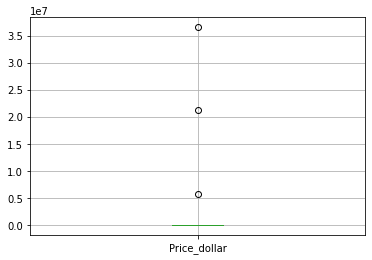

In [56]:
# Since we have just transformed the Price ranges we will have to recheck for missing values and outliers again
data.boxplot(column='Price_dollar')

There are 3 outliers present in the data.

In [57]:
# Pandas allows you to get quantiles using quantile function
Q1 = data['Price_dollar'].quantile(0.25)
Q3 = data['Price_dollar'].quantile(0.75)
IQR = Q3 - Q1
LowerCutoff = Q1 - IQR * 1.5
HigherCutoff = Q3 + IQR * 1.5
print(Q1, Q3 ,IQR, LowerCutoff, HigherCutoff)

2944.053097543094 8015.316451028299 5071.263353485205 -4662.841932684713 15622.211481256105


In [58]:
# Let's see which entries are outliers
outliers=data[(data.Price_dollar < LowerCutoff) |(data.Price_dollar > HigherCutoff)]

In [59]:
outliers

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price,PaidCurrency,Price_dollar
9,2020-08-16,10480,Pants,1 star,6914,Female,Prepaid Card,Express,19.0,£ 4032878.5368307503,British Pound,5.713238e+06
16,2020-08-17,10487,Pants,2 star,5783,Female,Credit Card,Economy,19.0,£ 25773831.320659,British Pound,3.651288e+07
29,2020-08-02,10500,Jeans,1 star,9410,Unspecified,Direct Deposit,Mail,5.0,"$21,312,321.13",American Dollar,2.131232e+07


In [60]:
data.drop([9,16,29],axis=0,inplace=True)

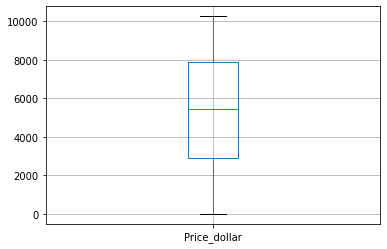

In [61]:
data.boxplot(column='Price_dollar')

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 88 entries, 0 to 99
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           88 non-null     datetime64[ns]
 1   CustomerID     88 non-null     int64         
 2   ProductType    88 non-null     object        
 3   Rating         88 non-null     object        
 4   Total_Ratings  88 non-null     int64         
 5   Gender         88 non-null     category      
 6   PaymentMode    88 non-null     object        
 7   ShippingMode   88 non-null     string        
 8   ShippingTime   88 non-null     float64       
 9   Price          87 non-null     string        
 10  PaidCurrency   88 non-null     object        
 11  Price_dollar   88 non-null     float64       
dtypes: category(1), datetime64[ns](1), float64(2), int64(2), object(4), string(2)
memory usage: 8.4+ KB


In [ ]:
# lets try to filter entries with product type average expense is more than 6000
#data.groupby('ProductType').filter(lambda val:val['Price_dollar'].mean()>6000)

### Encoding

#### LabelEncoder

Scikit-learn(__sklearn__) is a famous machine learning library which provides a number of data preprocessing methods and machine learning algorithms. 


In [64]:
from sklearn.preprocessing import LabelEncoder

In [65]:
data[['CustomerID','ProductType','Rating','ShippingMode']].head(9)

,CustomerID,ProductType,Rating,ShippingMode
0,10471,Coats/Jackets,1 star,Economy
1,10472,Dresses,2 star,Mail
2,10473,Coats/Jackets,2 star,Mail
5,10476,Coats/Jackets,2 star,Mail
6,10477,Coats/Jackets,5 star,Mail
7,10478,Jeans,1 star,Mail
8,10479,Pants,4 star,Express
10,10481,Dresses,2 star,Economy
11,10482,Pants,5 star,Mail


In [66]:
encoded_data=data.copy()

In [67]:
encoded_data.Rating=LabelEncoder().fit_transform(data.Rating)
encoded_data.head()

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price,PaidCurrency,Price_dollar
0,2020-08-16,10471,Coats/Jackets,0,8736,Female,Credit Card,Economy,17.0,₹ 675036.2138626401,Indian Rupee,9266.222108
1,2020-08-02,10472,Dresses,1,8547,Unspecified,Ewallet,Mail,12.0,"€ 2,315.53",Euro,2834.426380
2,2020-08-08,10473,Coats/Jackets,1,9833,Unspecified,Prepaid Card,Mail,10.0,₹ 611426.29122378,Indian Rupee,8393.048700
5,2020-08-28,10476,Coats/Jackets,1,5347,Female,Direct Deposit,Mail,20.0,<NA>,,0.000000
6,2020-08-08,10477,Coats/Jackets,4,9406,Unspecified,Direct Deposit,Mail,14.0,£ 6610.077565000001,British Pound,9364.265534


#### Mapping

In [68]:
encoded_data=data.copy()

In [69]:
def map_rating(i):
    if i=='1 star':
        return 0
    elif i=='2 star':
        return 1
    elif i=='3 star':
        return 2
    elif i=='4 star':
        return 3
    elif i=='5 star':
        return 4
    else:
        return -1

In [70]:
encoded_data.Rating=encoded_data.Rating.map(map_rating)
encoded_data.head()

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price,PaidCurrency,Price_dollar
0,2020-08-16,10471,Coats/Jackets,0,8736,Female,Credit Card,Economy,17.0,₹ 675036.2138626401,Indian Rupee,9266.222108
1,2020-08-02,10472,Dresses,1,8547,Unspecified,Ewallet,Mail,12.0,"€ 2,315.53",Euro,2834.426380
2,2020-08-08,10473,Coats/Jackets,1,9833,Unspecified,Prepaid Card,Mail,10.0,₹ 611426.29122378,Indian Rupee,8393.048700
5,2020-08-28,10476,Coats/Jackets,1,5347,Female,Direct Deposit,Mail,20.0,<NA>,,0.000000
6,2020-08-08,10477,Coats/Jackets,4,9406,Unspecified,Direct Deposit,Mail,14.0,£ 6610.077565000001,British Pound,9364.265534


#### OneHotEncoder

In [88]:
from sklearn.preprocessing import OneHotEncoder
encoded_data=data.copy()
encoded_data[['CustomerID','ProductType','Rating','ShippingMode']].head()

,CustomerID,ProductType,Rating,ShippingMode
0,10471,Coats/Jackets,1 star,Economy
1,10472,Dresses,2 star,Mail
2,10473,Coats/Jackets,2 star,Mail
5,10476,Coats/Jackets,2 star,Mail
6,10477,Coats/Jackets,5 star,Mail


In [89]:
lbe=LabelEncoder()
encoded_data['ProductType_lbl']=lbe.fit_transform(encoded_data.ProductType)

In [90]:
encoded_data.head(10)

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price,PaidCurrency,Price_dollar,ProductType_lbl
0,2020-08-16,10471,Coats/Jackets,1 star,8736,Female,Credit Card,Economy,17.000000,₹ 675036.2138626401,Indian Rupee,9266.222108,1
1,2020-08-02,10472,Dresses,2 star,8547,Unspecified,Ewallet,Mail,12.000000,"€ 2,315.53",Euro,2834.426380,2
2,2020-08-08,10473,Coats/Jackets,2 star,9833,Unspecified,Prepaid Card,Mail,10.000000,₹ 611426.29122378,Indian Rupee,8393.048700,1
5,2020-08-28,10476,Coats/Jackets,2 star,5347,Female,Direct Deposit,Mail,20.000000,<NA>,,0.000000,1
6,2020-08-08,10477,Coats/Jackets,5 star,9406,Unspecified,Direct Deposit,Mail,14.000000,£ 6610.077565000001,British Pound,9364.265534,1
7,2020-08-08,10478,Jeans,1 star,8554,Unspecified,Direct Deposit,Mail,18.000000,"$4,287.06",American Dollar,4287.060000,4
8,2020-08-01,10479,Pants,4 star,9630,Male,Direct Deposit,Express,12.822222,£ 3010.212198,British Pound,4264.462263,5
10,2020-08-21,10481,Dresses,2 star,7750,Female,Direct Deposit,Economy,17.000000,"€ 3,702.54",Euro,4532.256999,2
11,2020-08-18,10482,Pants,5 star,7816,Female,Mobile Payment,Mail,10.000000,"€ 6,580.20",Euro,8054.783339,5
12,2020-08-11,10483,Cardigan,4 star,7021,Unspecified,Cash,Express,6.000000,"$6,756.94",American Dollar,6756.940000,0


In [91]:
ohe = OneHotEncoder(handle_unknown='ignore')

In [92]:
out=pd.DataFrame(ohe.fit_transform(encoded_data[['ProductType_lbl']]).toarray())
out.head(10)

,0,1,2,3,4,5,6
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
# Merge the dataframe
encoded_data = encoded_data.join(out)

In [94]:
encoded_data.drop(['CustomerID','Rating','ShippingMode','Total_Ratings','Gender','PaymentMode',
                   'ShippingTime','Price','Price_dollar','PaidCurrency'],axis=1).head(10)

,Date,ProductType,ProductType_lbl,0,1,2,3,4,5,6
0,2020-08-16,Coats/Jackets,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2020-08-02,Dresses,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2020-08-08,Coats/Jackets,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,2020-08-28,Coats/Jackets,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,2020-08-08,Coats/Jackets,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,2020-08-08,Jeans,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,2020-08-01,Pants,5,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10,2020-08-21,Dresses,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
11,2020-08-18,Pants,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12,2020-08-11,Cardigan,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


#### Pandas Dummies

In [95]:
# We can simply do the similar thing using pandas dummies
encoded_data=data.copy()

In [96]:
encoded_data=pd.get_dummies(encoded_data,columns=['ProductType'])

In [97]:
encoded_data.drop(['CustomerID','Rating','ShippingMode','Total_Ratings','Gender','PaymentMode',
                   'ShippingTime','Price','Price_dollar','PaidCurrency'],axis=1).head()

,Date,ProductType_Cardigan,ProductType_Coats/Jackets,ProductType_Dresses,ProductType_Hats,ProductType_Jeans,ProductType_Pants,ProductType_Shirts/Tops
0,2020-08-16,0,1,0,0,0,0,0
1,2020-08-02,0,0,1,0,0,0,0
2,2020-08-08,0,1,0,0,0,0,0
5,2020-08-28,0,1,0,0,0,0,0
6,2020-08-08,0,1,0,0,0,0,0


It is more convenient to use dummies as it reduces a lot of clutter in the code.

#### Binarizer

### Scaling

#### StandardScaler

In [98]:
data.head()

,Date,CustomerID,ProductType,Rating,Total_Ratings,Gender,PaymentMode,ShippingMode,ShippingTime,Price,PaidCurrency,Price_dollar
0,2020-08-16,10471,Coats/Jackets,1 star,8736,Female,Credit Card,Economy,17.0,₹ 675036.2138626401,Indian Rupee,9266.222108
1,2020-08-02,10472,Dresses,2 star,8547,Unspecified,Ewallet,Mail,12.0,"€ 2,315.53",Euro,2834.426380
2,2020-08-08,10473,Coats/Jackets,2 star,9833,Unspecified,Prepaid Card,Mail,10.0,₹ 611426.29122378,Indian Rupee,8393.048700
5,2020-08-28,10476,Coats/Jackets,2 star,5347,Female,Direct Deposit,Mail,20.0,<NA>,,0.000000
6,2020-08-08,10477,Coats/Jackets,5 star,9406,Unspecified,Direct Deposit,Mail,14.0,£ 6610.077565000001,British Pound,9364.265534


In [99]:
data[['Total_Ratings','ShippingTime','Price_dollar']].agg([np.mean,max,min])

,Total_Ratings,ShippingTime,Price_dollar
mean,7626.375,12.770707,5297.132511
max,9965.000,20.000000,10252.171025
min,5024.000,5.000000,0.000000


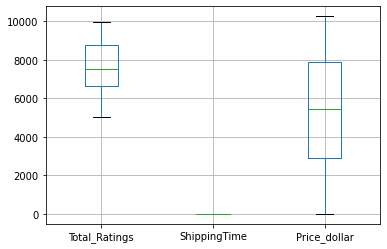

In [100]:
data[['Total_Ratings','ShippingTime','Price_dollar']].boxplot()

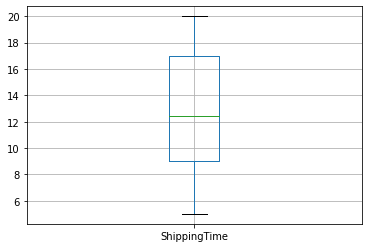

In [101]:
data[['ShippingTime']].boxplot()

Clearly, there is difference is scales in features.

In [102]:
scaled_data=data.copy()

In [103]:
from sklearn.preprocessing import StandardScaler

In [104]:
scl_tr=StandardScaler() # scaling total ratings
scl_st=StandardScaler() # scaling shipping time
scl_pd=StandardScaler() # scaling price in dollars

In [105]:
scaled_data.Total_Ratings=scl_tr.fit_transform(scaled_data[['Total_Ratings']])
scaled_data.ShippingTime=scl_st.fit_transform(scaled_data[['ShippingTime']])
scaled_data.Price_dollar=scl_pd.fit_transform(scaled_data[['Price_dollar']])

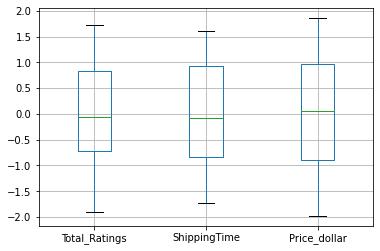

In [106]:
scaled_data[['Total_Ratings','ShippingTime','Price_dollar']].boxplot()

In [107]:
scaled_data[['Total_Ratings','ShippingTime','Price_dollar']]

,Total_Ratings,ShippingTime,Price_dollar
0,0.813898,0.936850,1.485148
1,0.675269,-0.170723,-0.921491
2,1.618537,-0.613752,1.158425
5,-1.671898,1.601393,-1.982073
6,1.305337,0.272306,1.521833
...,...,...,...
94,-0.952345,-1.278295,1.548813
95,-1.126915,-1.721324,-1.373470
96,1.325141,0.050792,-1.326387
97,-0.199784,-0.613752,0.982003


#### MinMaxScaler

In [108]:
scaled_data=data.copy()

In [109]:
from sklearn.preprocessing import MinMaxScaler

In [110]:
mcl_tr=MinMaxScaler() # scaling total ratings
mcl_st=MinMaxScaler() # scaling shipping time
mcl_pd=MinMaxScaler() # scaling price in dollars

In [111]:
scaled_data.Total_Ratings=mcl_tr.fit_transform(scaled_data[['Total_Ratings']])
scaled_data.ShippingTime=mcl_st.fit_transform(scaled_data[['ShippingTime']])
scaled_data.Price_dollar=mcl_pd.fit_transform(scaled_data[['Price_dollar']])

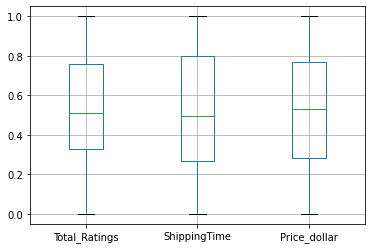

In [112]:
scaled_data[['Total_Ratings','ShippingTime','Price_dollar']].boxplot()

In [ ]:
from sklearn.preprocessing import Binarizer

In [ ]:
scaled_data=data.copy()

In [ ]:
bl=Binarizer(5000)

In [ ]:
# Let's say we have divide data where purchase were made more than 5000
scaled_data['Price_5000']=bl.fit_transform(scaled_data[['Price_dollar']])

In [ ]:
scaled_data[['Price_dollar','Price_5000']].head()

##### Saving Preprocessed DataFrame

In [ ]:
data.head()

In [ ]:
data.to_csv('Bello_Fashions_processed.csv',index=False)

MinMaxScaler scales data between 0-1

### Advance Manipulation

#### Plotting and Styling

#### Plotting

In [ ]:
data.head()

In [ ]:
def getCount(data,cat):
    '''
    data: DataFrame
    cat: category name  
    '''
    rre={'Category':[],'Length':[]}
    for grp,gata in data.groupby(cat):
        rre['Category'].append(grp)
        rre['Length'].append(len(gata))
    return pd.DataFrame(rre)

##### Most Popular Product Type

In [ ]:
pt_count=getCount(data,'ProductType')
pt_count.set_index('Category',inplace=True)

In [ ]:
pt_count.plot(kind='bar',title='Product Sales')

##### Most Preferred Payment Mode

In [ ]:
pt_count=getCount(data,'PaymentMode')
pt_count.set_index('Category',inplace=True)
pt_count.plot(kind='bar',title='Payment Mode')

##### Most Preferred Shipping Mode

In [ ]:
pt_count=getCount(data,'ShippingMode')
pt_count.set_index('Category',inplace=True)
pt_count.plot(kind='bar',title='Payment Mode')

##### Average Price/ShippingTime of products per category

In [ ]:
aprice=data.groupby('ProductType')['Price_dollar'].agg(np.mean)

In [ ]:
aprice.plot(kind='bar')

In [ ]:
aship=data.groupby('ProductType')['ShippingTime'].agg(np.mean)
aship.plot(kind='bar')

##### Check the distribution of Shipping time

In [ ]:
data[['ShippingTime']].plot.hist()

##### Pie Chart

In [ ]:
pt_count=getCount(data,'PaymentMode')
pt_count.set_index('Category',inplace=True)
pt_count.Length.plot.pie(title='Payment Mode')

#### Highlighting Price >5000

In [ ]:
styled_data=data.head(10).style

In [ ]:
styled_data=data.drop(['Date','Price'],axis=1).head(10).style
def price_range(price):
    out=[]
    for i in price:
        if float(i)>5000:
            # if price is greater than 5000 then color is light blue
            out.append("background-color : #e1eff6")
        else:
            # if price is less than 5000 then color is light pink
            out.append("background-color : #eccbd9")
    return out
styled_data.apply(price_range,subset=['Price_dollar'])

#### Styling whole table using CSS styles

In [ ]:
styled_data=data.drop(['Date','Price'],axis=1).head(10).style


styles = [
    dict(selector="tr:hover",props=[("background-color", "#eccbd9")]),
    dict(selector="th:hover",props=[("background-color", "#eccbd9")]),
    dict(selector="th", props=[('background-color','#4f6d7a'),
                               ("font-size", "12px"),
                               ("text-align", "center"),
                               ('color', '#ffffff'),
                              ('border','1px solid #dbe9ee')]),
    dict(selector='tbody', props=[('color', '#449dd1'),]),
    dict(selector='tr', props=[('background-color','#e1eff6'),
                                ('color', '#449dd1'),
                                ('font-family','Helvetica')]),
    dict(selector='td',props=[('border','1px solid #166088'),
                             ("font-size", "10px")])
]

styled_data.set_table_styles(styles)

#### Magnification

In [ ]:
styled_data=data.drop(['Date','Price'],axis=1).head(10).style

def magnify():
    return [dict(selector="th",
                 props=[("font-size", "7pt")]),
            dict(selector="td",
                 props=[('padding', "4px 4px"),]),
            dict(selector="th:hover",
                 props=[("font-size", "13pt")]),
            dict(selector="tr:hover td:hover",
                 props=[('max-width', '200px'),
                        ('font-size', '14pt'),
                       ('color', '#4f6d7a')])]




styles = [
    dict(selector="tr:hover",props=[("background-color", "#eccbd9")]),
    dict(selector="th:hover",props=[("background-color", "#eccbd9")]),
    dict(selector="th", props=[('background-color','#4f6d7a'),
                               ("font-size", "120%"),
                               ("text-align", "center"),
                               ('color', '#ffffff'),
                              ('border','1px solid #dbe9ee')]),
    dict(selector='tbody', props=[('color', '#449dd1'),]),
    dict(selector='tr', props=[('background-color','#e1eff6'),
                                ('color', '#449dd1'),
                                ('font-family','Helvetica')]),
    dict(selector='td',props=[('border','1px solid #166088'),])]

styles.extend(magnify())
styled_data.set_table_styles(styles)